Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape : (10000, 32, 32, 3)


/tmp/ipykernel_2849/2845845546.py:54: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.5560 - loss: 1.3177 - val_accuracy: 0.6575 - val_loss: 1.0327
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.7113 - loss: 0.8456 - val_accuracy: 0.6860 - val_loss: 0.9780
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.7586 - loss: 0.6999 - val_accuracy: 0.6865 - val_loss: 0.9716
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.6465 - loss: 1.0565

Test Accuracy : 64.65 %
Test Loss     : 1.0565


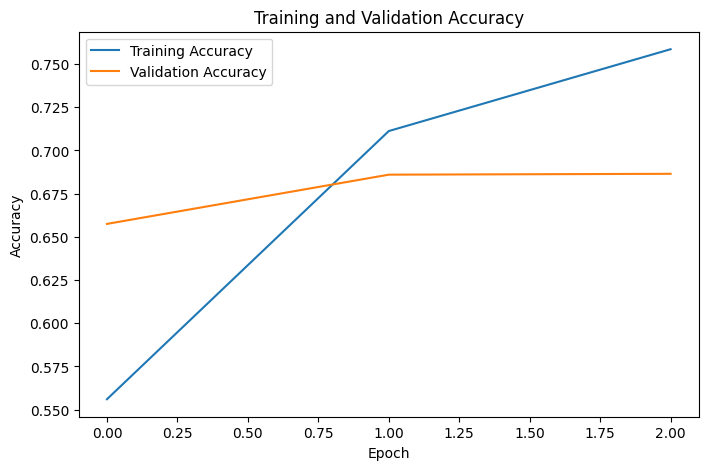

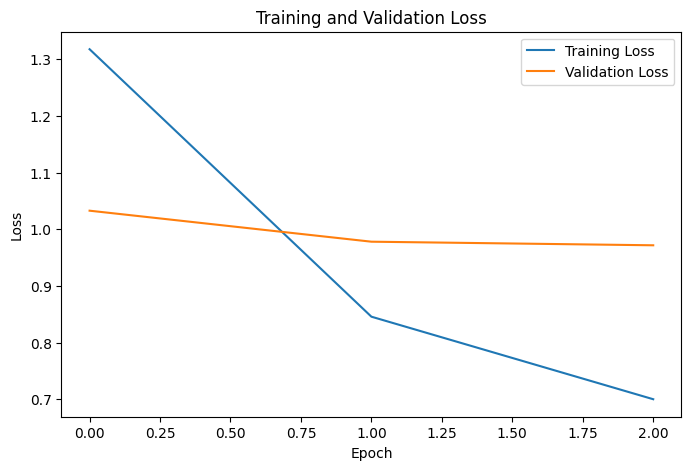

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step


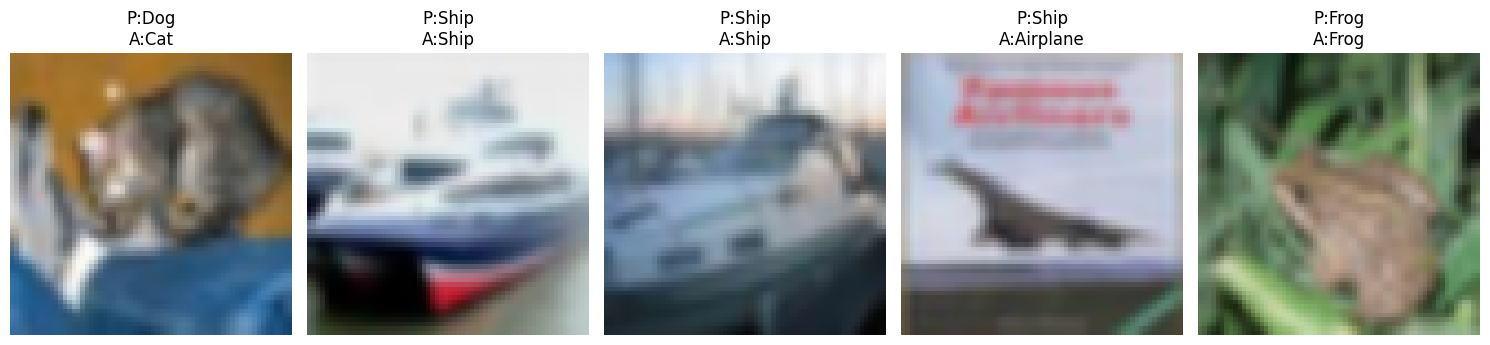

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Single Image Prediction
Actual Class   : Airplane
Predicted Class: Airplane


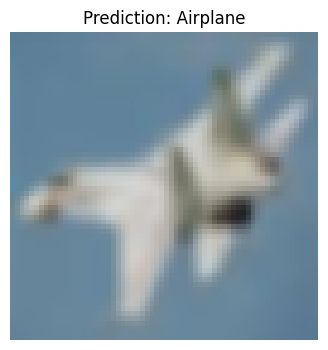

In [5]:
# ============================================================
# Task 2 - Transfer Learning: Image Classification
# Model: MobileNetV2
# Dataset: CIFAR-10
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# ============================================================
# Load CIFAR-10 Dataset
# ============================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

# ============================================================
# Reduce Dataset Size (Colab RAM Friendly)
# ============================================================

X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# ============================================================
# Resize Images for MobileNetV2
# ============================================================

X_train = tf.image.resize(X_train, (64, 64))
X_test = tf.image.resize(X_test, (64, 64))

# ============================================================
# Preprocessing
# ============================================================

X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)

# ============================================================
# Load Pre-trained MobileNetV2
# ============================================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze base model
base_model.trainable = False

# ============================================================
# Add Custom Layers
# ============================================================

x = base_model.output
x = GlobalAveragePooling2D()(x)

output_layer = Dense(
    10,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output_layer
)

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Train Model
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=16,
    validation_split=0.2
)

# ============================================================
# Evaluate Model
# ============================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", round(accuracy * 100, 2), "%")
print("Test Loss     :", round(loss, 4))

# ============================================================
# Accuracy Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

# ============================================================
# Loss Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

# ============================================================
# Class Names
# ============================================================

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# ============================================================
# Predictions
# ============================================================

predictions = model.predict(X_test)

# ============================================================
# Visualize Predictions
# ============================================================

plt.figure(figsize=(15,6))

for i in range(5):

    plt.subplot(1,5,i+1)

    image = (X_test[i] + 1) / 2

    plt.imshow(image)

    predicted_class = np.argmax(predictions[i])
    actual_class = y_test[i][0]

    plt.title(
        f"P:{class_names[predicted_class]}\nA:{class_names[actual_class]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# Single Image Prediction
# ============================================================

sample_index = 10

sample_image = X_test[sample_index]

prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)

predicted_class = np.argmax(prediction)

print("\nSingle Image Prediction")
print("Actual Class   :", class_names[y_test[sample_index][0]])
print("Predicted Class:", class_names[predicted_class])

plt.figure(figsize=(4,4))
plt.imshow((sample_image + 1) / 2)
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis('off')
plt.show()